In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
df = pd.read_csv('IMDB_reviews.csv', encoding='latin', engine='python', on_bad_lines='skip')
df.head()

,URL,Title,Release Year,Poster,Genre,Director,Cast,Length,IMDB Rating,Metascore,Votes,Gross,Review Title,Review Text,Rating By User,Review Date,Review Author
0,https://www.imdb.com/title/tt0137523/?ref_=ttl...,Fight Club,1999,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Drama,David Fincher,"['Brad Pitt', 'Edward Norton', 'Meat Loaf']",2h 19m,8.8,67.0,"2,267,031",$37.03M,A great movie you can watch again and again,Because you'll probably be confused the first ...,10/10,11 February 2020,Pukeonthestreet
1,https://www.imdb.com/title/tt0137523/?ref_=ttl...,Fight Club,1999,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Drama,David Fincher,"['Brad Pitt', 'Edward Norton', 'Meat Loaf']",2h 19m,8.8,67.0,"2,267,031",$37.03M,Superb,"Superb, and truly one of the greatest movies o...",10/10,19 April 2014,grantss
2,https://www.imdb.com/title/tt0137523/?ref_=ttl...,Fight Club,1999,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Drama,David Fincher,"['Brad Pitt', 'Edward Norton', 'Meat Loaf']",2h 19m,8.8,67.0,"2,267,031",$37.03M,"Crazy, Cult, Plot Twist, Awesome = Fight Club",I have no words about this film. This is maste...,10/10,28 July 2021,jack_o_hasanov_imdb
3,https://www.imdb.com/title/tt0137523/?ref_=ttl...,Fight Club,1999,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Drama,David Fincher,"['Brad Pitt', 'Edward Norton', 'Meat Loaf']",2h 19m,8.8,67.0,"2,267,031",$37.03M,Welcome to movie heaven!,"Let's ignore the advice and talk about ""Fight ...",10/10,16 December 2013,gogoschka-1
4,https://www.imdb.com/title/tt0137523/?ref_=ttl...,Fight Club,1999,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Drama,David Fincher,"['Brad Pitt', 'Edward Norton', 'Meat Loaf']",2h 19m,8.8,67.0,"2,267,031",$37.03M,Crazy good,"So rewatchable. The acting is amazing, the sto...",10/10,12 October 2019,trosati-98923


In [ ]:
df.isnull().sum()

,0
URL,0
Title,0
Release Year,0
Poster,0
Genre,0
Director,919
Cast,1199
Length,919
IMDB Rating,0
Metascore,705


In [ ]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(76393, 17)
Index(['URL', 'Title', 'Release Year', 'Poster', 'Genre', 'Director', 'Cast',
       'Length', 'IMDB Rating', 'Metascore', 'Votes', 'Gross', 'Review Title',
       'Review Text', 'Rating By User', 'Review Date', 'Review Author'],
      dtype='object')
URL                object
Title              object
Release Year        int64
Poster             object
Genre              object
Director           object
Cast               object
Length             object
IMDB Rating       float64
Metascore         float64
Votes              object
Gross              object
Review Title       object
Review Text        object
Rating By User     object
Review Date        object
Review Author      object
dtype: object


In [ ]:
df.describe()

,Release Year,IMDB Rating,Metascore
count,76393.000000,76393.000000,75688.000000
mean,2000.770804,7.949838,78.410633
std,13.992129,0.498210,11.392822
min,1953.000000,6.500000,41.000000
25%,1997.000000,7.600000,72.000000
50%,2002.000000,7.900000,80.000000
75%,2011.000000,8.400000,87.000000
max,2020.000000,9.300000,96.000000


In [3]:
df["review_word_count"] = df["Review Text"].apply(lambda x: len(str(x).split()))
df["review_char_count"] = df["Review Text"].apply(lambda x: len(str(x)))

In [ ]:
print("\nReview Word Count Stats:")
print(df["review_word_count"].describe())


Review Word Count Stats:
count    76393.000000
mean       206.170997
std        174.667043
min          4.000000
25%         97.000000
50%        156.000000
75%        246.000000
max       2016.000000
Name: review_word_count, dtype: float64


In [ ]:
print("\nTop 5 Longest Reviews (Word Count):")
print(df[["Title", "review_word_count"]].sort_values(by="review_word_count", ascending=False).head())


Top 5 Longest Reviews (Word Count):
                                 Title  review_word_count
61285        Aguirre, the Wrath of God               2016
6934                         Midsommar               1873
22803           No Country for Old Men               1768
76226  What Ever Happened to Baby Jane               1766
6174                         Midsommar               1708


In [ ]:
print("\nTop 5 Shortest Reviews (Word Count):")
print(df[["Title", "review_word_count"]].sort_values(by="review_word_count").head())


Top 5 Shortest Reviews (Word Count):
                      Title  review_word_count
44007             Chinatown                  4
41453  Natural Born Killers                  6
36314          Blade Runner                  9
921              Fight Club                 12
47075              Sin City                 13


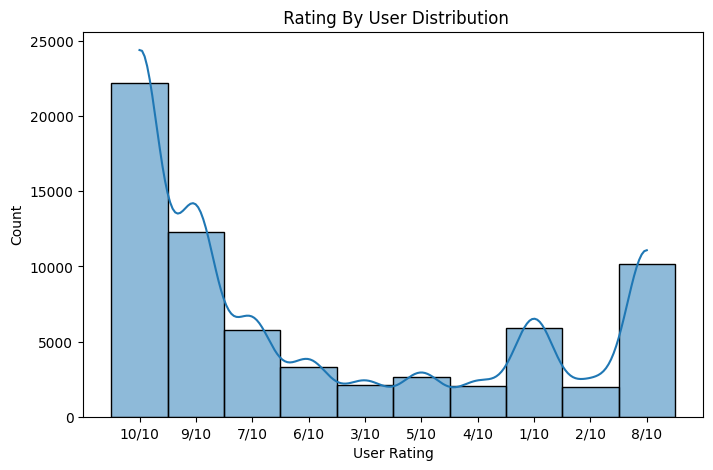

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rating By User"], bins=30, kde=True)
plt.title(" Rating By User Distribution")
plt.xlabel("User Rating")
plt.show()

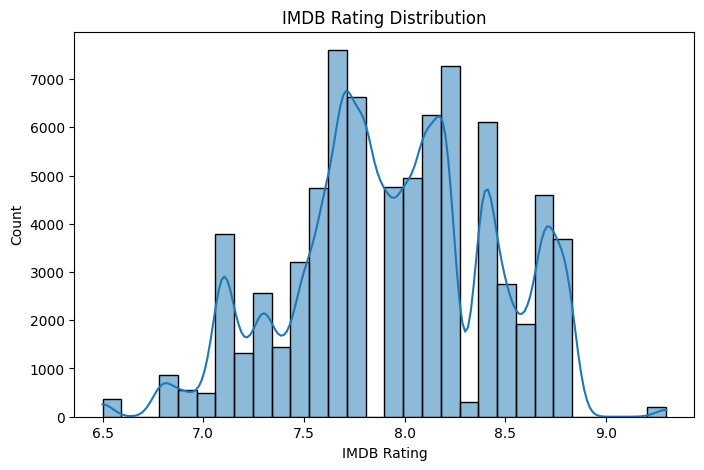

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["IMDB Rating"], bins=30, kde=True)
plt.title("IMDB Rating Distribution")
plt.xlabel("IMDB Rating")
plt.show()

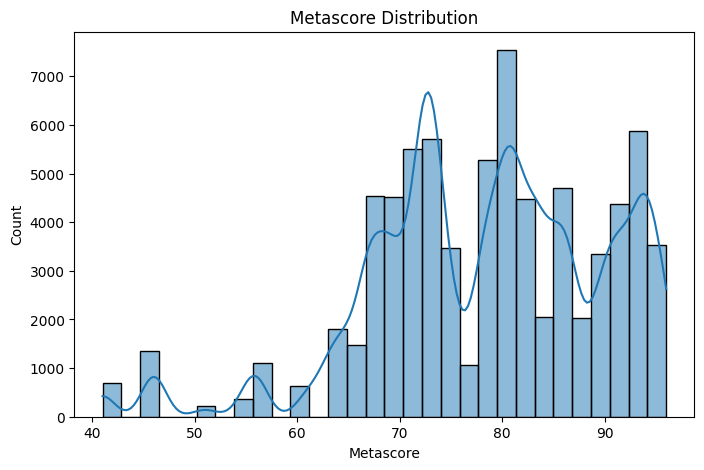

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Metascore"].dropna(), bins=30, kde=True)
plt.title("Metascore Distribution")
plt.xlabel("Metascore")
plt.show()

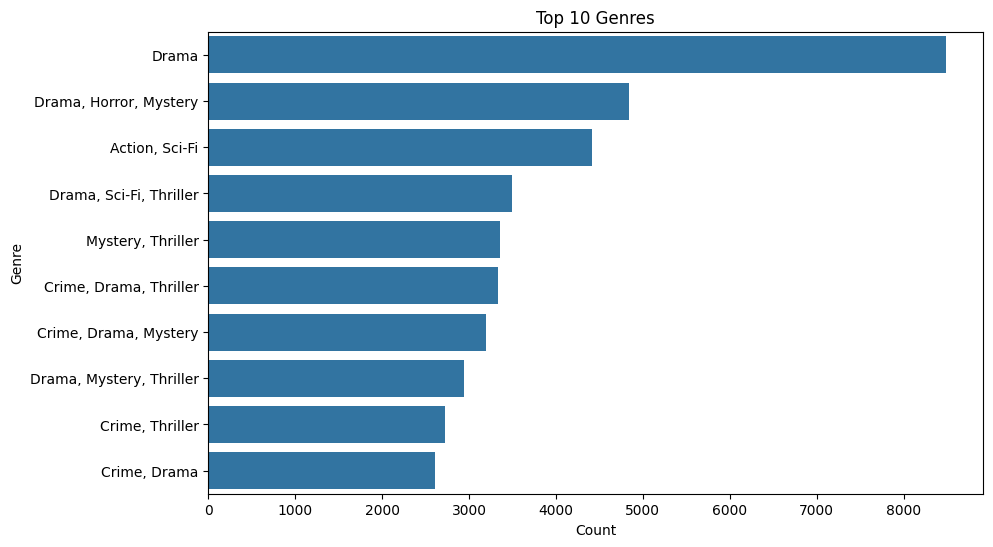

In [ ]:
plt.figure(figsize=(10,6))
top_genres = df["Genre"].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.show()


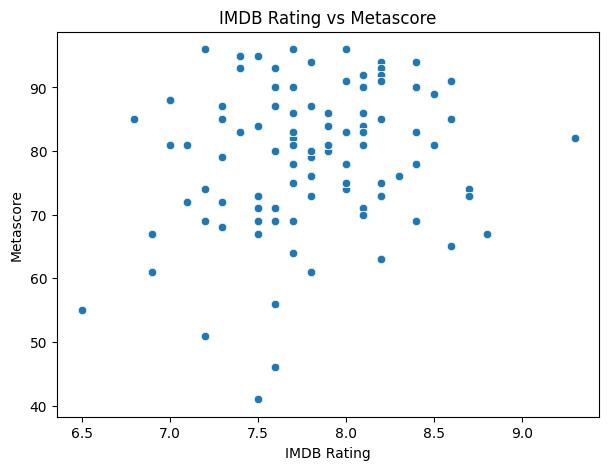

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="IMDB Rating", y="Metascore", data=df)
plt.title("IMDB Rating vs Metascore")
plt.show()

In [59]:
df = df.dropna(subset=['Review Text', 'Rating By User'])
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())
df['Votes'] = df['Votes'].fillna(0)

In [60]:
def extract_rating(x):
    try:
        return int(str(x).split('/')[0])
    except:
        return None

df['Rating By User Numeric'] = df['Rating By User'].apply(extract_rating)
df = df.dropna(subset=['Rating By User Numeric'])

In [61]:
def sentiment(x):
    if x >= 7:
        return 2
    elif x >= 5:
        return 1
    else:
        return 0

df['sentiment'] = df['Rating By User Numeric'].apply(sentiment)

In [62]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['clean_review'] = df['Review Text'].apply(preprocess_text)

In [8]:
df['review_length'] = df['clean_review'].apply(len)
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False).astype(float)
df['votes_log'] = np.log1p(df['Votes'])

In [9]:
tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df['clean_review'])

In [58]:
df['Genre'] = df['Genre'].fillna('Unknown')
encoder = OneHotEncoder(handle_unknown='ignore')
X_genre = encoder.fit_transform(df[['Genre']])

In [11]:
numeric_features = df[['review_length', 'word_count', 'votes_log',
                       'IMDB Rating', 'Metascore']].values

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_numeric_scaled = scaler.fit_transform(numeric_features)

In [12]:
from scipy.sparse import hstack

X = hstack([X_text, X_genre, X_numeric_scaled])
y = df['sentiment']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Naive Bayes:

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 81.44382679929784

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.56      0.63      2400
           1       0.42      0.01      0.02      1190
           2       0.83      0.97      0.89     10082

    accuracy                           0.81     13672
   macro avg       0.66      0.51      0.51     13672
weighted avg       0.78      0.81      0.77     13672



Support Vector Machine(SVM):

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack

scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(numeric_features)

X = hstack([X_text, X_genre, X_numeric_scaled])
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = LinearSVC(class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 82.42393212404914

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.74      0.72      2400
           1       0.29      0.31      0.30      1190
           2       0.92      0.91      0.91     10082

    accuracy                           0.82     13672
   macro avg       0.64      0.65      0.65     13672
weighted avg       0.83      0.82      0.83     13672



Random Forest:

In [ ]:
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = hstack([X_text, X_genre, X_numeric_scaled])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_dense, y_train)

y_pred = model.predict(X_test_dense)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred))

Accuracy: 81.27559976594499
              precision    recall  f1-score   support

           0       0.82      0.47      0.60      2400
           1       1.00      0.00      0.00      1190
           2       0.81      0.99      0.89     10082

    accuracy                           0.81     13672
   macro avg       0.88      0.49      0.50     13672
weighted avg       0.83      0.81      0.76     13672



AdaBoost:

In [ ]:
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

X = hstack([X_text, X_genre, X_numeric_scaled])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
model.fit(X_train_dense, y_train)

y_pred = model.predict(X_test_dense)

print(" Adaboost Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred))

 Adaboost Accuracy: 77.70626097132826
              precision    recall  f1-score   support

           0       0.82      0.26      0.40      2400
           1       0.00      0.00      0.00      1190
           2       0.77      0.99      0.87     10082

    accuracy                           0.78     13672
   macro avg       0.53      0.42      0.42     13672
weighted avg       0.72      0.78      0.71     13672



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Long Short Term Memory(LSTM):

In [63]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
texts = df['clean_review'].astype(str).values
labels = df['sentiment'].values
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)
loss, acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)
y_pred = lstm_model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7358 - loss: 0.7316 - val_accuracy: 0.7427 - val_loss: 0.6951
Epoch 2/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7357 - loss: 0.6968 - val_accuracy: 0.7427 - val_loss: 0.6555
Epoch 3/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7984 - loss: 0.5721 - val_accuracy: 0.8318 - val_loss: 0.5152
Epoch 4/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8482 - loss: 0.4544 - val_accuracy: 0.8418 - val_loss: 0.4374
Epoch 5/5
770/770 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8645 - loss: 0.3846 - val_accuracy: 0.8541 - val_loss: 0.4209
428/428 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8419 - loss: 0.4470
Test Accuracy: 0.8418666124343872
428/428 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

           0       0.71      0.72      0.71      2400
           1       0.00      0.00      0.00      1190
           2       0.87      0.97      0.92   

BERT:

In [14]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
texts = df['clean_review'].astype(str).tolist()
labels = df['sentiment'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(
    X_train,
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    X_test,
    truncation=True,
    padding=True,
    max_length=64
)
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, y_train)
test_dataset = ReviewDataset(test_encodings, y_test)

bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=500
)
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset
)
trainer.train()
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.651497
1000,0.526732
1500,0.521626
2000,0.519014
2500,0.483799
3000,0.485608
3500,0.474334
4000,0.478723
4500,0.466758
5000,0.458580


              precision    recall  f1-score   support

           0       0.73      0.73      0.73      2400
           1       0.36      0.06      0.10      1190
           2       0.88      0.96      0.92     10082

    accuracy                           0.85     13672
   macro avg       0.66      0.59      0.58     13672
weighted avg       0.81      0.85      0.82     13672



OUTPUT:

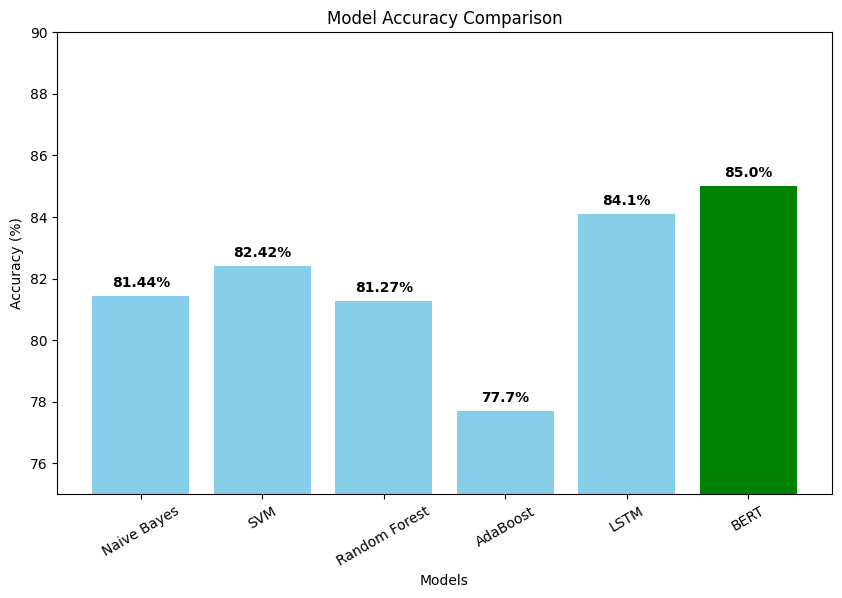

In [ ]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'SVM', 'Random Forest',
          'AdaBoost', 'LSTM', 'BERT']

accuracies = [81.44, 82.42, 81.27, 77.70, 84.10, 85.00]

colors = ['skyblue', 'skyblue', 'skyblue',
          'skyblue', 'skyblue', 'green']

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracies, color=colors)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(75, 90)

for i in range(len(models)):
    plt.text(i, accuracies[i] + 0.3,
             f"{accuracies[i]}%",
             ha='center',
             fontweight='bold')

plt.xticks(rotation=30)
plt.show()

In [15]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [16]:
import torch
import spacy
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

In [17]:
bert_model.to(device)
bert_model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [18]:
import spacy
nlp = spacy.load("en_core_web_sm")

def extract_aspects_dependency(sentences):
    aspects_all = []

    for doc in nlp.pipe(sentences, batch_size=128):
        aspects = []

        for token in doc:
            if token.dep_ == "amod" and token.head.pos_ == "NOUN":
                aspects.append(token.head.lemma_.lower())
            if token.pos_ == "ADJ":
                for child in token.children:
                    if child.dep_ == "nsubj" and child.pos_ == "NOUN":
                        aspects.append(child.lemma_.lower())

        aspects = [
            word for word in aspects
            if len(word) > 2 and word.isalpha()
        ]

        aspects_all.append(list(set(aspects))[:3])

    return aspects_all


print("Extracting aspects using dependency parsing...")
df["aspects"] = extract_aspects_dependency(
    df["clean_review"].astype(str).tolist()
)
print("Smart aspect extraction done!")

Extracting aspects using dependency parsing...
Smart aspect extraction done!


In [19]:
aspect_data = []

for idx, row in df.iterrows():
    for aspect in row["aspects"]:
        aspect_data.append((
            idx,
            row["clean_review"],
            aspect,
            row["sentiment"]
        ))

aspect_df = pd.DataFrame(
    aspect_data,
    columns=["review_id", "sentence", "aspect", "true_label"]
)

print("Total aspect samples:", len(aspect_df))

Total aspect samples: 204034


In [20]:
encodings = tokenizer(
    aspect_df["sentence"].tolist(),
    aspect_df["aspect"].tolist(),
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

In [21]:
import torch

class FastDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

In [22]:
aspect_dataset = FastDataset(encodings)

aspect_loader = torch.utils.data.DataLoader(
    aspect_dataset,
    batch_size=256,
    shuffle=False
)

In [23]:
from tqdm import tqdm

all_preds = []

with torch.no_grad():
    for batch in tqdm(aspect_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

100%|██████████| 798/798 [05:39<00:00,  2.35it/s]


In [57]:
from sklearn.metrics import accuracy_score

aspect_df["pred_label"] = all_preds

aspect_accuracy = accuracy_score(
    aspect_df["true_label"],
    aspect_df["pred_label"]
)

print("Aspect-Based Accuracy: {:.2f}%".format(aspect_accuracy * 100))


Aspect-Based Accuracy: 85.74%


In [25]:
label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

aspect_df["Predicted_Sentiment"] = aspect_df["pred_label"].map(label_map)

In [26]:


perfect_output = (
    aspect_df
    .groupby("review_id")[["aspect", "Predicted_Sentiment"]]
    .apply(lambda x: dict(zip(x["aspect"], x["Predicted_Sentiment"])))
    .reset_index(name="aspect_sentiment")
)


perfect_output["Review Text"] = perfect_output["review_id"].map(df["clean_review"])


perfect_output = perfect_output[["Review Text", "aspect_sentiment"]]


perfect_output = perfect_output.reset_index(drop=True)

print(perfect_output.head(10))

                                         Review Text  \
0  youll probably confused first time around coin...   
1  superb truly one greatest movie timeit start s...   
2  word film masterpiece cult film found helpful ...   
3  let ignore advice talk fight club film milesto...   
4  rewatchable acting amazing story amazing secon...   
5  office worker spends time looking fulfilment v...   
6  lot people know never even heard filmgood see ...   
7  everything fight club simply amazing acting di...   
8  perhaps little long fight club wellmade brilli...   
9  wasnt prepared existential trip life thought g...   

                                    aspect_sentiment  
0  {'vote': 'Positive', 'review': 'Positive', 'ac...  
1  {'movie': 'Positive', 'direction': 'Positive',...  
2         {'review': 'Positive', 'vote': 'Positive'}  
3  {'energy': 'Positive', 'ride': 'Positive', 'te...  
4  {'movie': 'Positive', 'vote': 'Positive', 'rev...  
5  {'group': 'Positive', 'timeless': 'Positive', ... 

In [34]:
movie_aspects = {

    "acting", "actor", "actress", "performance", "cast", "role",
    "portrayal", "characterization", "chemistry", "presence",
    "supporting", "lead", "villain", "protagonist", "antagonist",


    "direction", "director", "filmmaker", "vision",
    "execution", "approach", "style",


    "story", "plot", "screenplay", "script", "writing",
    "narrative", "dialogue", "twist", "ending",
    "climax", "opening", "premise", "concept",
    "theme", "message", "pace", "pacing",


    "cinematography", "visual", "visuals", "camera",
    "shot", "lighting", "frame", "angle",
    "scene", "sequence", "imagery",


    "music", "sound", "soundtrack", "background",
    "score", "audio", "theme", "song",


    "editing", "production", "effects", "animation",
    "design", "costume", "makeup", "cgi",
    "set", "location", "choreography",


    "action", "drama", "comedy", "thriller",
    "romance", "horror", "suspense",
    "fantasy", "mystery", "crime",
    "adventure", "biography", "documentary",


    "emotion", "emotion", "impact", "experience",
    "feeling", "engagement", "entertainment",
    "enjoyment", "interest", "excitement",
    "tension", "atmosphere", "mood",


    "performance", "rating", "award", "nomination",
    "boxoffice", "success", "failure",

    "audience", "viewer", "fan",
    "expectation", "reaction"
}

In [35]:
def filter_movie_aspects(aspect_dict):
    if not isinstance(aspect_dict, dict):
        return {}

    filtered_dict = {
        aspect: sentiment
        for aspect, sentiment in aspect_dict.items()
        if aspect in movie_aspects
    }

    return filtered_dict

perfect_output["aspect_sentiment"] = perfect_output["aspect_sentiment"].apply(filter_movie_aspects)

In [41]:
def filter_movie_aspects(aspect_dict):
    if not isinstance(aspect_dict, dict):
        return {}

    return {
        aspect: sentiment
        for aspect, sentiment in aspect_dict.items()
        if aspect in movie_aspects
    }

perfect_output["aspect_sentiment"] = perfect_output["aspect_sentiment"].apply(filter_movie_aspects)

perfect_output = perfect_output[
    perfect_output["aspect_sentiment"].map(len) > 0
].reset_index(drop=True)

print(perfect_output.head(10))

                                         Review Text  \
0  youll probably confused first time around coin...   
1  superb truly one greatest movie timeit start s...   
2  office worker spends time looking fulfilment v...   
3  movie phenomenal liked every single actor stor...   
4  im much graphic violence film transcends wonde...   
5  im sure fact ed norton really grate film never...   
6  script tight theme fascinating acting incredib...   
7  solid acting amazing direction movie want keep...   
8  movie fight club recommended many friend saw i...   
9  fight club brash slap face consumerism working...   

                            aspect_sentiment Final_Classification  
0                      {'actor': 'Positive'}             Positive  
1                  {'direction': 'Positive'}             Positive  
2                     {'action': 'Positive'}             Positive  
3                      {'twist': 'Positive'}             Positive  
4                  {'direction': 'Positive'

In [42]:
perfect_output.to_csv("aspect_sentiment_dataset.csv", index=False)

In [47]:
filtered_aspect_df = aspect_df[
    aspect_df["aspect"].isin(movie_aspects)
].copy()

In [48]:
from sklearn.metrics import accuracy_score

aspect_accuracy = accuracy_score(
    filtered_aspect_df["true_label"],
    filtered_aspect_df["pred_label"]
)

print("Aspect-Based Accuracy After Dictionary: {:.2f}%".format(aspect_accuracy * 100))

Aspect-Based Accuracy After Dictionary: 86.34%


In [49]:
from sklearn.metrics import classification_report

print(classification_report(
    filtered_aspect_df["true_label"],
    filtered_aspect_df["pred_label"]
))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71      2859
           1       0.48      0.09      0.15      1999
           2       0.89      0.98      0.93     17164

    accuracy                           0.86     22022
   macro avg       0.69      0.59      0.60     22022
weighted avg       0.83      0.86      0.83     22022



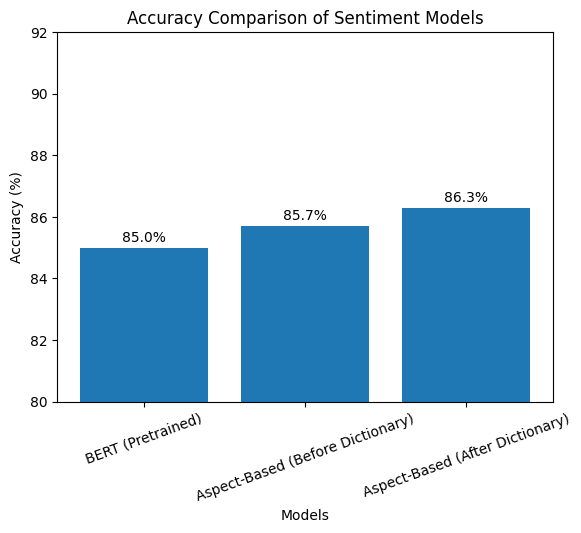

In [64]:
import matplotlib.pyplot as plt

bert_accuracy = 85.0
aspect_before = 85.7
aspect_after = 86.3

models = [
    "BERT (Pretrained)",
    "Aspect-Based (Before Dictionary)",
    "Aspect-Based (After Dictionary)"
]

accuracies = [bert_accuracy, aspect_before, aspect_after]

plt.figure()

bars = plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Sentiment Models")

plt.xticks(rotation=20)
plt.ylim(80, 92)
for i in range(len(models)):
    plt.text(i, accuracies[i] + 0.2,
             str(accuracies[i]) + "%",
             ha='center')
plt.show()